<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/LGBM%26XGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Dataset Analysis: LightGBM vs. XGBoost

## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv('/content/diabetes (1).csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Check for Missing Values and Descriptive Statistics

In [2]:
print("\nDescriptive Statistics:")
display(df.describe().T)

# Check for explicitly missing values
print("\nMissing values count per column:")
display(df.isnull().sum())

# Identify columns where 0 might indicate a missing value (medically implausible)
impute_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nNumber of 0 values in medically implausible columns:")
for col in impute_cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")



Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Missing values count per column:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Number of 0 values in medically implausible columns:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


## 3. Impute Missing Values (Zeros)

In [3]:
# Impute 0 values in specified columns with the median of their respective columns
for col in impute_cols:
    df[col] = df[col].replace(0, df[col].median())

print("\nNumber of 0 values after imputation:")
for col in impute_cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

print("\nDescriptive Statistics after imputation:")
display(df.describe().T)


Number of 0 values after imputation:
Glucose: 0 zeros
BloodPressure: 0 zeros
SkinThickness: 0 zeros
Insulin: 0 zeros
BMI: 0 zeros

Descriptive Statistics after imputation:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450911,6.875366,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 4. Explore Data Distributions (Histograms and Box Plots)

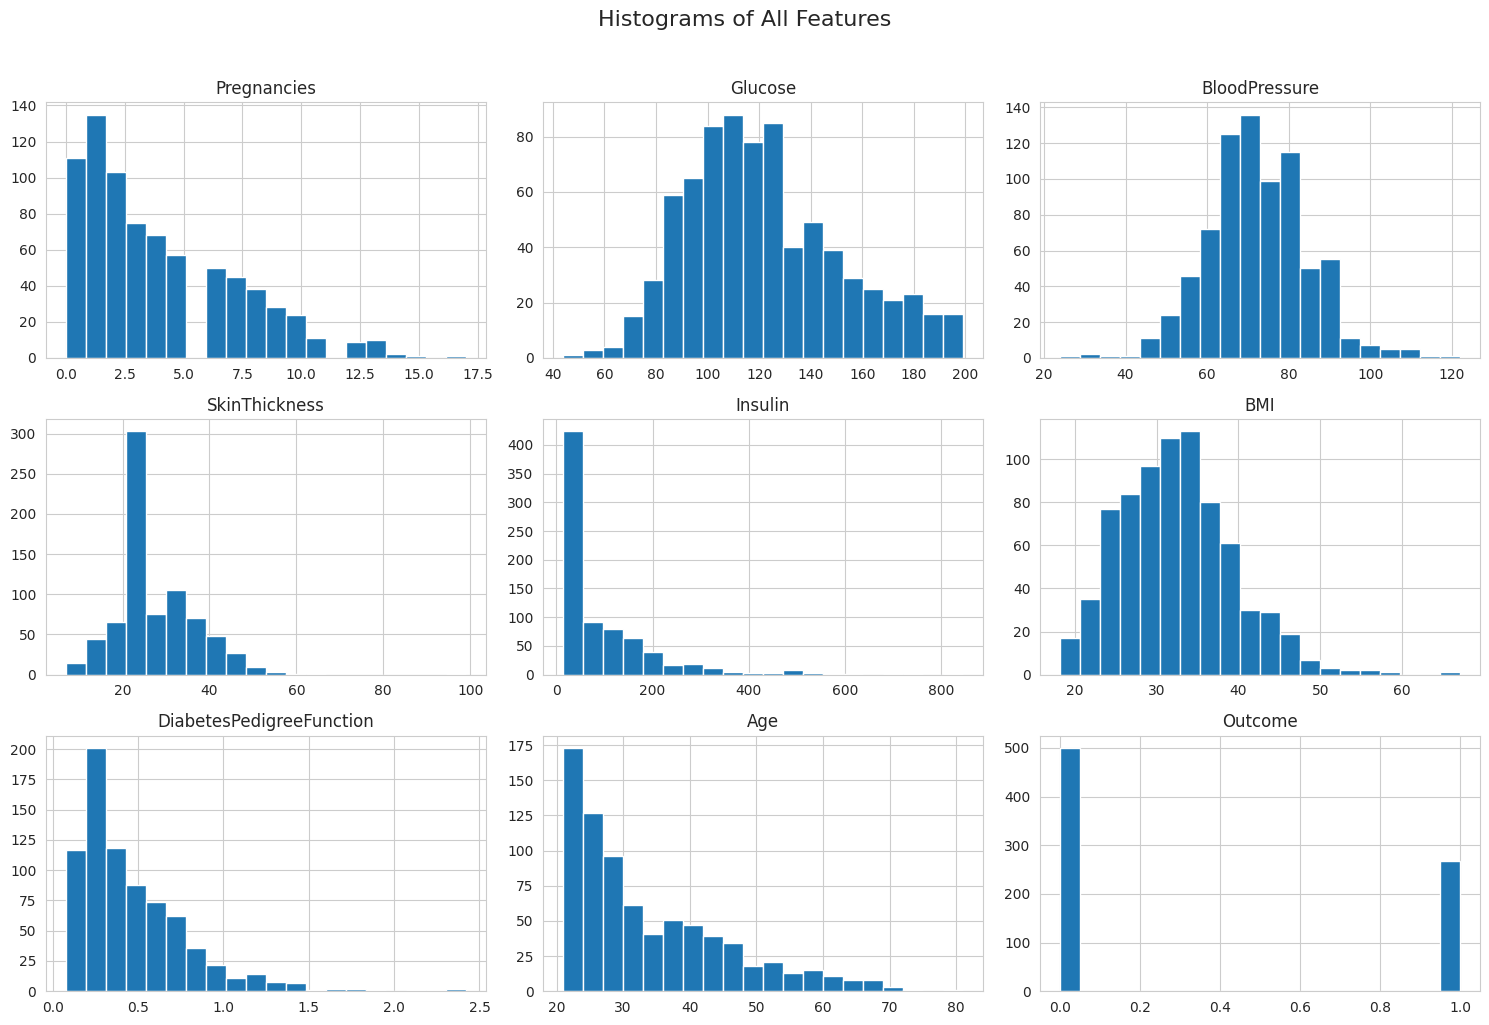

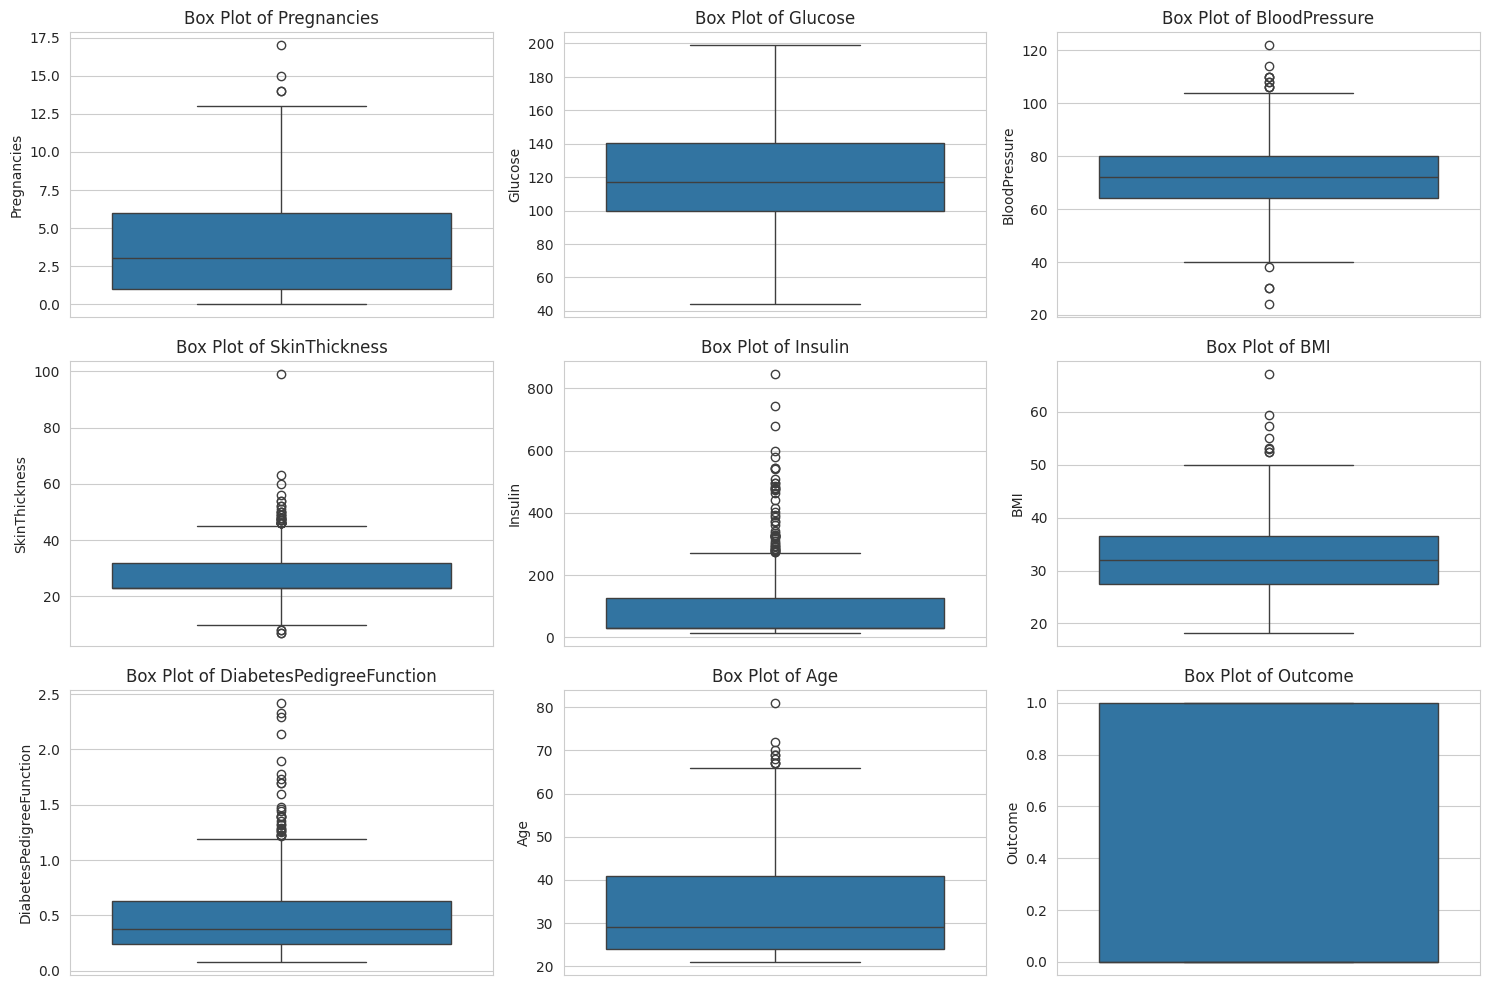

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create histograms for all features
df.hist(figsize=(15, 10), bins=20)
plt.suptitle('Histograms of All Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Create box plots for all features
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid based on number of columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

## 5. Visualize Relationships with Outcome

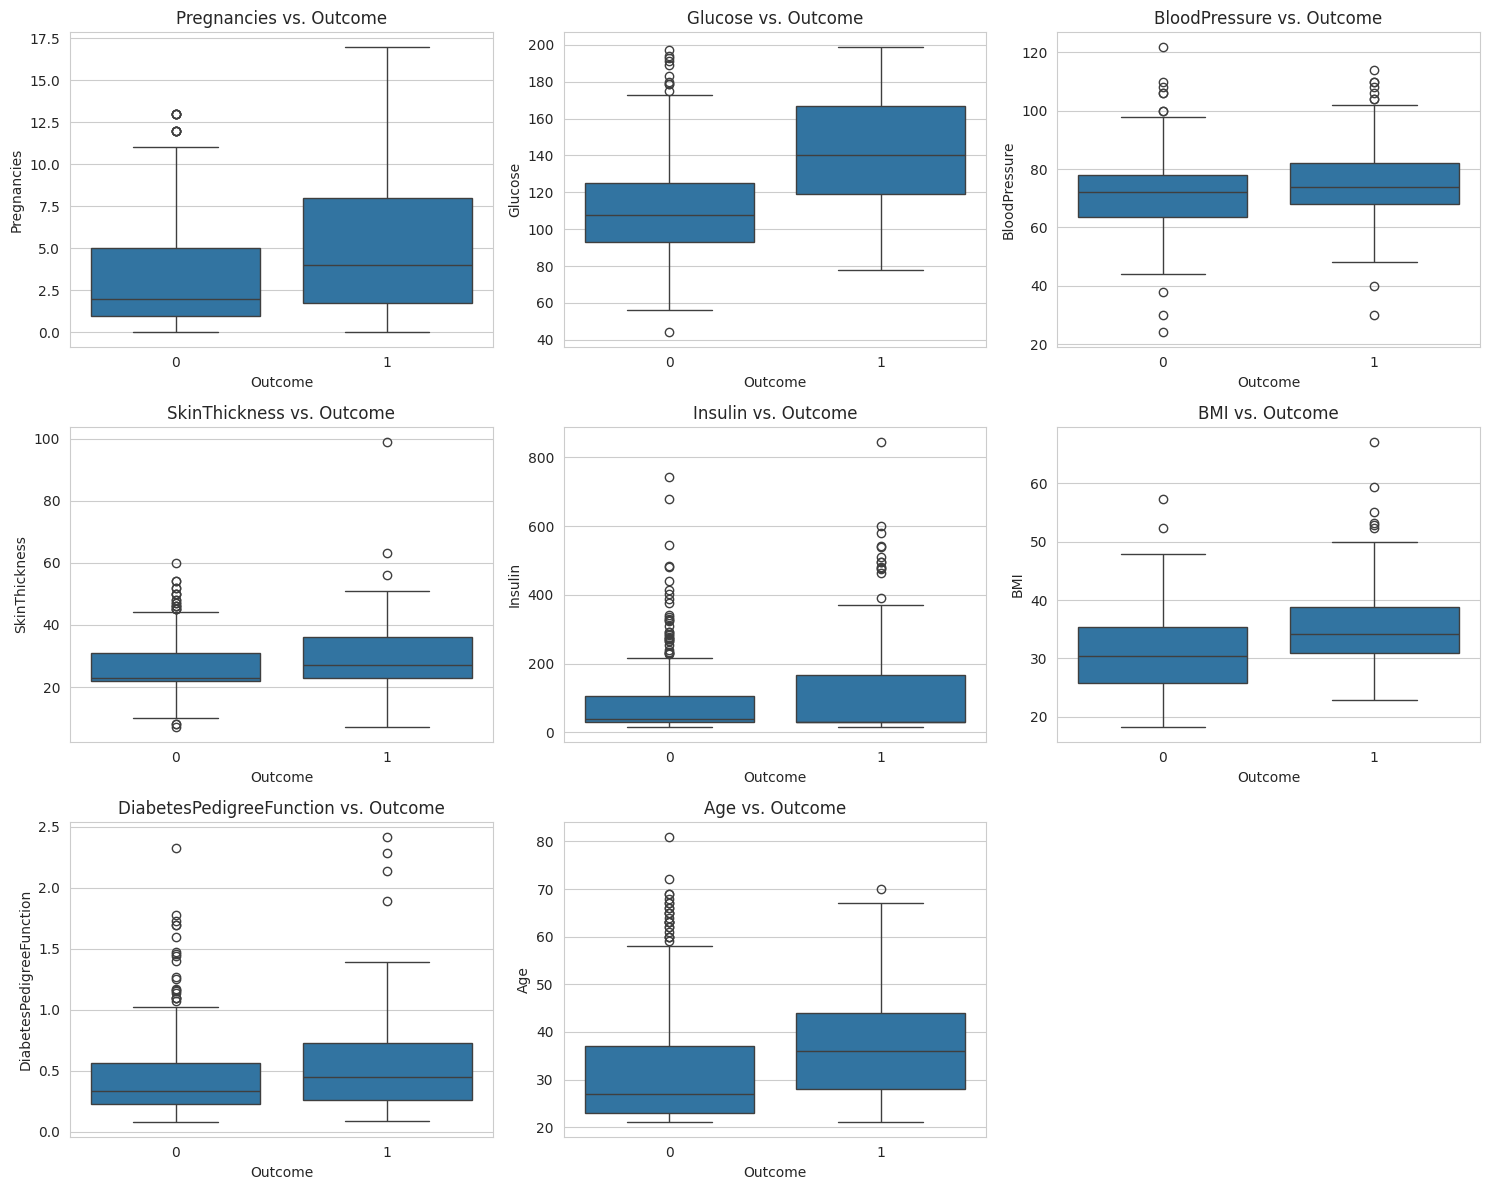

In [5]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]): # Exclude 'Outcome' column for feature plots
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} vs. Outcome')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

In [6]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## 7. Building Predictive Models

### 7.1 LightGBM Model

In [7]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize LightGBM Classifier
lgbm = lgb.LGBMClassifier(random_state=42)

# Train the model
lgbm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# Evaluate the model
print("LightGBM Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lgbm):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lgbm), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,Predicted 0,Predicted 1
Actual 0,80,20
Actual 1,22,32



Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.62      0.59      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



### 7.2 XGBoost Model

In [10]:
import xgboost as xgb

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# Evaluate the model
print("XGBoost Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_xgb), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Model Performance:
Accuracy: 0.7338
Precision: 0.6275
Recall: 0.5926
F1-Score: 0.6095
ROC AUC Score: 0.8096

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,81,19
Actual 1,22,32



Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



### 7.2 XGBoost Model

In [11]:
import xgboost as xgb

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# Evaluate the model
print("XGBoost Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_xgb), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Model Performance:
Accuracy: 0.7338
Precision: 0.6275
Recall: 0.5926
F1-Score: 0.6095
ROC AUC Score: 0.8096

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,81,19
Actual 1,22,32



Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

